# M02 — Thí nghiệm 1: Khảo sát Tối ưu Tiền xử lý & Kích thước ảnh

**Mã nhiệm vụ:** `M02`

**Người thực hiện:** Nguyên

**Mục tiêu:** Kiểm chứng Giả thuyết H1 — so sánh `pad_square` (đệm viền đen, giữ tỉ lệ) với `stretch` (ép vuông) trên 3 kích thước ảnh (`32x32`, `48x48`, `64x64`), tìm ra cấu hình Tiền xử lý + Kích thước tối ưu (Val Accuracy / Val Macro F1 cao nhất).

**Không sử dụng Deep Learning** — toàn bộ pipeline dùng đặc trưng thủ công (HOG) + SVM (scikit-learn).


## 0. Cấu hình chung

- Bộ phân loại khóa cứng theo `LOG-02`: `StandardScaler()` + `SVC(kernel='rbf', C=10.0, gamma='scale', class_weight='balanced')`.
- Bộ đặc trưng khóa cứng: `HOG Gray` với `orientations=9`, `pixels_per_cell=(8,8)`, `cells_per_block=(2,2)` (riêng `32x32` có thêm biến thể `pixels_per_cell=(4,4)`).

In [11]:
import os
import cv2
import glob
import time
import json
import numpy as np
import pandas as pd
from skimage.feature import hog
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Đã import xong toàn bộ thư viện cần thiết.")


Đã import xong toàn bộ thư viện cần thiết.


In [12]:
DATASET_DIR = r"E:\Nguyen\AIL303m_FUDN_SUM26\paper\cropped_dataset"

# Notebook giả định cấu trúc thư mục chuẩn kiểu ImageFolder:
#   cropped_dataset/
#       train/<ten_lop>/*.jpg (hoặc .png)
#       val/<ten_lop>/*.jpg
# Nếu dataset của bạn có tên thư mục con khác (vd: "Train"/"Validation"),
# hãy sửa TRAIN_SUBDIR / VAL_SUBDIR bên dưới.
TRAIN_SUBDIR = "train"
VAL_SUBDIR = "val"

TRAIN_DIR = os.path.join(DATASET_DIR, TRAIN_SUBDIR)
VAL_DIR = os.path.join(DATASET_DIR, VAL_SUBDIR)

IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".ppm")

def list_split(split_dir):
    # Trả về (samples, classes) cho một thư mục train/val dạng ImageFolder.
    # samples: list (filepath, label). Sắp xếp cả lớp và tên file để đảm bảo
    # thứ tự đọc CỐ ĐỊNH giữa các lần chạy -> kết quả tái lập được.
    if not os.path.isdir(split_dir):
        raise FileNotFoundError(
            f"Không tìm thấy thư mục: {split_dir}\n"
            f"-> Hãy kiểm tra lại DATASET_DIR / TRAIN_SUBDIR / VAL_SUBDIR."
        )
    samples = []
    classes = sorted([d for d in os.listdir(split_dir)
                       if os.path.isdir(os.path.join(split_dir, d))])
    for cls in classes:
        cls_dir = os.path.join(split_dir, cls)
        for fname in sorted(os.listdir(cls_dir)):
            if fname.lower().endswith(IMG_EXTS):
                samples.append((os.path.join(cls_dir, fname), cls))
    return samples, classes

train_samples, train_classes = list_split(TRAIN_DIR)
val_samples, val_classes = list_split(VAL_DIR)

assert train_classes == val_classes, "Danh sách lớp giữa train và val không khớp nhau!"

print(f"Số lớp: {len(train_classes)}")
print(f"Số ảnh train: {len(train_samples)}")
print(f"Số ảnh val:   {len(val_samples)}")
print("Danh sách lớp:", train_classes)


Số lớp: 47
Số ảnh train: 6605
Số ảnh val:   824
Danh sách lớp: ['B.8a', 'Camera', 'I.407a', 'I.409', 'I.434a', 'P.102', 'P.103a', 'P.104', 'P.106a_Xe tải', 'P.107', 'P.111', 'P.117_', 'P.123a', 'P.123b', 'P.124a_', 'P.124c', 'P.124d', 'P.127_40', 'P.127_50', 'P.127_60', 'P.127_80', 'P.129', 'P.130', 'P.131a', 'P.137', 'P.139', 'R.301e', 'R.302a', 'R.303', 'R.415a', 'S.505a_Xe máy', 'S.505a_Xe tải', 'S.505a_Xe tải và công', 'W.201a', 'W.201b', 'W.203c', 'W.205a', 'W.205b', 'W.205c', 'W.207', 'W.210', 'W.221b', 'W.224', 'W.225', 'W.239b_', 'W.245a', 'W.246a']


## 1. Bước 1 — Hàm tiền xử lý `stretch` và `pad_square`

- `stretch`: `cv2.resize` trực tiếp về `target_size x target_size` (bóp méo tỉ lệ nếu ảnh không vuông).
- `pad_square`: thu phóng theo cạnh dài nhất rồi đệm viền đen (`cv2.copyMakeBorder`, giá trị 0) để thành hình vuông mà không bóp méo tỉ lệ.

**Lưu ý kỹ thuật (quan trọng cho tính đúng đắn):** phép suy luận được chọn **theo hướng scale** thay vì cố định `INTER_AREA`:
- Khi **thu nhỏ** ảnh (ảnh gốc lớn hơn kích thước đích) → `cv2.INTER_AREA` (chống răng cưa tốt).
- Khi **phóng to** ảnh (ảnh gốc nhỏ hơn kích thước đích) → `cv2.INTER_LINEAR` (mịn, không vỡ hạt).

Dùng `INTER_AREA` để phóng to (như bản cũ) sẽ cho ảnh kém chất lượng gần giống nearest-neighbor, ảnh hưởng trực tiếp đến đặc trưng HOG ở các size lớn (48/64).

In [13]:
def _pick_interpolation(src_h, src_w, target_size):
    # Chọn phép nội suy theo HƯỚNG scale:
    #   - Thu nhỏ (ảnh gốc lớn hơn đích)  -> INTER_AREA (sắc nét, ít răng cưa).
    #   - Phóng to (ảnh gốc nhỏ hơn đích) -> INTER_LINEAR (mịn, không vỡ hạt).
    # Dùng cạnh dài nhất để quyết định vì đó là cạnh chi phối tỉ lệ scale.
    return cv2.INTER_AREA if max(src_h, src_w) >= target_size else cv2.INTER_LINEAR

def resize_stretch(img, target_size):
    # Chế độ 'stretch': ép ảnh về hình vuông target_size x target_size, có thể bóp méo tỉ lệ.
    h, w = img.shape[:2]
    interp = _pick_interpolation(h, w, target_size)
    return cv2.resize(img, (target_size, target_size), interpolation=interp)

def resize_pad_square(img, target_size):
    # Chế độ 'pad_square': giữ nguyên tỉ lệ, đệm viền đen đối xứng cho thành hình vuông.
    h, w = img.shape[:2]
    L = max(h, w)
    scale = target_size / L
    new_w, new_h = max(1, round(w * scale)), max(1, round(h * scale))
    interp = _pick_interpolation(h, w, target_size)
    resized = cv2.resize(img, (new_w, new_h), interpolation=interp)

    pad_w = target_size - new_w
    pad_h = target_size - new_h
    top = pad_h // 2
    bottom = pad_h - top
    left = pad_w // 2
    right = pad_w - left

    if len(img.shape) == 3:
        border_value = [0, 0, 0]
    else:
        border_value = 0

    padded = cv2.copyMakeBorder(
        resized, top, bottom, left, right,
        borderType=cv2.BORDER_CONSTANT, value=border_value
    )
    # Sau khi đệm, ảnh LUÔN đúng target_size x target_size (pad_w, pad_h >= 0),
    # nên KHÔNG cần resize lại (tránh làm mờ thừa). Chỉ kiểm tra phòng hờ bằng assert.
    assert padded.shape[:2] == (target_size, target_size), \
        f"Kích thước sau pad sai: {padded.shape[:2]} != {(target_size, target_size)}"
    return padded

RESIZE_FUNCS = {
    "stretch": resize_stretch,
    "pad_square": resize_pad_square,
}

print("Đã định nghĩa xong 2 hàm resize: resize_stretch, resize_pad_square")
print("Nội suy tự chọn theo hướng scale: thu nhỏ -> INTER_AREA, phóng to -> INTER_LINEAR")


Đã định nghĩa xong 2 hàm resize: resize_stretch, resize_pad_square
Nội suy tự chọn theo hướng scale: thu nhỏ -> INTER_AREA, phóng to -> INTER_LINEAR


## 2. Bước 2 — Trích xuất đặc trưng `HOG Gray` và trích ma trận đặc trưng

In [14]:
def imread_unicode(path):
    # cv2.imread KHÔNG đọc được đường dẫn chứa ký tự Unicode (dấu tiếng Việt) trên Windows.
    # np.fromfile mở file bằng Python (hỗ trợ Unicode) rồi cv2.imdecode giải mã trong bộ nhớ.
    try:
        data = np.fromfile(path, dtype=np.uint8)
    except (OSError, ValueError):
        return None
    if data.size == 0:
        return None
    return cv2.imdecode(data, cv2.IMREAD_COLOR)

def extract_hog_gray(img_resized, pixels_per_cell=(8, 8), cells_per_block=(2, 2), orientations=9):
    # Chuyển ảnh sang xám và trích HOG chuẩn.
    if len(img_resized.shape) == 3:
        gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
    else:
        gray = img_resized
    feat = hog(
        gray,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        block_norm="L2-Hys",
        feature_vector=True,
    )
    return feat

def build_feature_matrix(samples, target_size, mode, pixels_per_cell=(8, 8)):
    # Đọc ảnh, resize theo mode, trích HOG Gray, trả về (X, y).
    resize_fn = RESIZE_FUNCS[mode]
    X, y = [], []
    skipped = 0
    for filepath, label in samples:
        img = imread_unicode(filepath)
        if img is None:
            skipped += 1
            continue
        img_resized = resize_fn(img, target_size)
        feat = extract_hog_gray(img_resized, pixels_per_cell=pixels_per_cell)
        X.append(feat)
        y.append(label)
    if skipped:
        print(f"    [CẢNH BÁO] Bỏ qua {skipped}/{len(samples)} ảnh không đọc được.")
    return np.array(X, dtype=np.float32), np.array(y)

print("Đã định nghĩa xong extract_hog_gray() và build_feature_matrix() (đọc ảnh hỗ trợ đường dẫn Unicode)")


Đã định nghĩa xong extract_hog_gray() và build_feature_matrix() (đọc ảnh hỗ trợ đường dẫn Unicode)


## 3. Bước 2 — Ma trận thí nghiệm: 6 cấu hình

| Mã TN | Size | Mode | pixels_per_cell |
|---|---|---|---|
| TN1.1 | 32x32 | stretch | (4,4) |
| TN1.2 | 32x32 | pad_square | (4,4) |
| TN1.3 | 48x48 | stretch | (8,8) |
| TN1.4 | 48x48 | pad_square | (8,8) |
| TN1.5 | 64x64 | stretch | (8,8) |
| TN1.6 | 64x64 | pad_square | (8,8) |

> Ghi chú: với `32x32`, dùng `pixels_per_cell=(4,4)` để đủ số block như đề bài yêu cầu.

In [15]:
EXPERIMENTS = [
    {"code": "TN1.1", "size": 32, "mode": "stretch",    "ppc": (4, 4)},
    {"code": "TN1.2", "size": 32, "mode": "pad_square",  "ppc": (4, 4)},
    {"code": "TN1.3", "size": 48, "mode": "stretch",    "ppc": (8, 8)},
    {"code": "TN1.4", "size": 48, "mode": "pad_square",  "ppc": (8, 8)},
    {"code": "TN1.5", "size": 64, "mode": "stretch",    "ppc": (8, 8)},
    {"code": "TN1.6", "size": 64, "mode": "pad_square",  "ppc": (8, 8)},
]

results_m02 = []

for exp in EXPERIMENTS:
    code_name = exp["code"]
    size = exp["size"]
    mode = exp["mode"]
    ppc = exp["ppc"]
    print(f"--- Đang chạy {code_name}: size={size}, mode={mode}, ppc={ppc} ---")

    X_train, y_train = build_feature_matrix(train_samples, size, mode, pixels_per_cell=ppc)
    X_val, y_val = build_feature_matrix(val_samples, size, mode, pixels_per_cell=ppc)

    n_features = X_train.shape[1]

    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=10.0, gamma="scale", class_weight="balanced",
                     random_state=RANDOM_STATE)),
    ])

    t0 = time.time()
    clf.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = clf.predict(X_val)
    acc = accuracy_score(y_val, y_pred) * 100
    f1_macro = f1_score(y_val, y_pred, average="macro") * 100

    results_m02.append({
        "Mã TN": code_name,
        "Kích thước": f"{size}x{size}",
        "Chế độ Resize": mode,
        "pixels_per_cell": str(ppc),
        "Số chiều HOG": n_features,
        "Val Accuracy (%)": round(acc, 2),
        "Val Macro F1 (%)": round(f1_macro, 2),
        "Thời gian Train (s)": round(train_time, 2),
    })
    print(f"    -> Val Acc={acc:.2f}%  Val F1={f1_macro:.2f}%  n_features={n_features}  train_time={train_time:.2f}s")

df_results_m02 = pd.DataFrame(results_m02)
df_results_m02


--- Đang chạy TN1.1: size=32, mode=stretch, ppc=(4, 4) ---
    -> Val Acc=95.15%  Val F1=92.16%  n_features=1764  train_time=11.59s
--- Đang chạy TN1.2: size=32, mode=pad_square, ppc=(4, 4) ---
    -> Val Acc=94.90%  Val F1=92.19%  n_features=1764  train_time=12.14s
--- Đang chạy TN1.3: size=48, mode=stretch, ppc=(8, 8) ---
    -> Val Acc=96.48%  Val F1=95.95%  n_features=900  train_time=4.55s
--- Đang chạy TN1.4: size=48, mode=pad_square, ppc=(8, 8) ---
    -> Val Acc=96.12%  Val F1=94.56%  n_features=900  train_time=4.59s
--- Đang chạy TN1.5: size=64, mode=stretch, ppc=(8, 8) ---
    -> Val Acc=95.87%  Val F1=94.04%  n_features=1764  train_time=10.15s
--- Đang chạy TN1.6: size=64, mode=pad_square, ppc=(8, 8) ---
    -> Val Acc=95.51%  Val F1=93.44%  n_features=1764  train_time=10.22s


,Mã TN,Kích thước,Chế độ Resize,pixels_per_cell,Số chiều HOG,Val Accuracy (%),Val Macro F1 (%),Thời gian Train (s)
0,TN1.1,32x32,stretch,"(4, 4)",1764,95.15,92.16,11.59
1,TN1.2,32x32,pad_square,"(4, 4)",1764,94.90,92.19,12.14
2,TN1.3,48x48,stretch,"(8, 8)",900,96.48,95.95,4.55
3,TN1.4,48x48,pad_square,"(8, 8)",900,96.12,94.56,4.59
4,TN1.5,64x64,stretch,"(8, 8)",1764,95.87,94.04,10.15
5,TN1.6,64x64,pad_square,"(8, 8)",1764,95.51,93.44,10.22


In [16]:
# Lưu bảng kết quả ra CSV để đính kèm báo cáo
os.makedirs("outputs", exist_ok=True)
df_results_m02.to_csv("outputs/M02_results_6_configs.csv", index=False, encoding="utf-8-sig")
print("Đã lưu: outputs/M02_results_6_configs.csv")
df_results_m02


Đã lưu: outputs/M02_results_6_configs.csv


,Mã TN,Kích thước,Chế độ Resize,pixels_per_cell,Số chiều HOG,Val Accuracy (%),Val Macro F1 (%),Thời gian Train (s)
0,TN1.1,32x32,stretch,"(4, 4)",1764,95.15,92.16,11.59
1,TN1.2,32x32,pad_square,"(4, 4)",1764,94.90,92.19,12.14
2,TN1.3,48x48,stretch,"(8, 8)",900,96.48,95.95,4.55
3,TN1.4,48x48,pad_square,"(8, 8)",900,96.12,94.56,4.59
4,TN1.5,64x64,stretch,"(8, 8)",1764,95.87,94.04,10.15
5,TN1.6,64x64,pad_square,"(8, 8)",1764,95.51,93.44,10.22


## 4. Bước 3 — Phân tích & Kết luận

In [17]:
# So sánh stretch vs pad_square theo từng size
pivot = df_results_m02.pivot_table(
    index="Kích thước", columns="Chế độ Resize", values="Val Macro F1 (%)"
)
print("So sánh Val Macro F1 (%) theo Size x Mode:")
print(pivot)
print()

for size in pivot.index:
    stretch_f1 = pivot.loc[size].get("stretch", None)
    pad_f1 = pivot.loc[size].get("pad_square", None)
    if stretch_f1 is not None and pad_f1 is not None:
        winner = "stretch" if stretch_f1 >= pad_f1 else "pad_square"
        print(f"- Size {size}: stretch={stretch_f1:.2f}% vs pad_square={pad_f1:.2f}% -> "
              f"'{winner}' tốt hơn ở size này.")

print()
best_row = df_results_m02.loc[df_results_m02["Val Macro F1 (%)"].idxmax()]
print("=" * 60)
print("CẤU HÌNH CHIẾN THẮNG (dựa trên Val Macro F1 cao nhất, thực đo trên dữ liệu):")
print(f"  Mã TN         : {best_row['Mã TN']}")
print(f"  Kích thước    : {best_row['Kích thước']}")
print(f"  Chế độ Resize : {best_row['Chế độ Resize']}")
print(f"  Val Accuracy  : {best_row['Val Accuracy (%)']}%")
print(f"  Val Macro F1  : {best_row['Val Macro F1 (%)']}%")
print(f"  Thời gian Train: {best_row['Thời gian Train (s)']}s")
print("=" * 60)

# Trích cấu hình chiến thắng.
WINNER_SIZE = int(best_row["Kích thước"].split("x")[0])
WINNER_MODE = best_row["Chế độ Resize"]
# Lấy trực tiếp tuple ppc từ danh sách EXPERIMENTS theo Mã TN (không dùng eval).
WINNER_PPC = next(e["ppc"] for e in EXPERIMENTS if e["code"] == best_row["Mã TN"])


So sánh Val Macro F1 (%) theo Size x Mode:
Chế độ Resize  pad_square  stretch
Kích thước                        
32x32               92.19    92.16
48x48               94.56    95.95
64x64               93.44    94.04

- Size 32x32: stretch=92.16% vs pad_square=92.19% -> 'pad_square' tốt hơn ở size này.
- Size 48x48: stretch=95.95% vs pad_square=94.56% -> 'stretch' tốt hơn ở size này.
- Size 64x64: stretch=94.04% vs pad_square=93.44% -> 'stretch' tốt hơn ở size này.

CẤU HÌNH CHIẾN THẮNG (dựa trên Val Macro F1 cao nhất, thực đo trên dữ liệu):
  Mã TN         : TN1.3
  Kích thước    : 48x48
  Chế độ Resize : stretch
  Val Accuracy  : 96.48%
  Val Macro F1  : 95.95%
  Thời gian Train: 4.55s


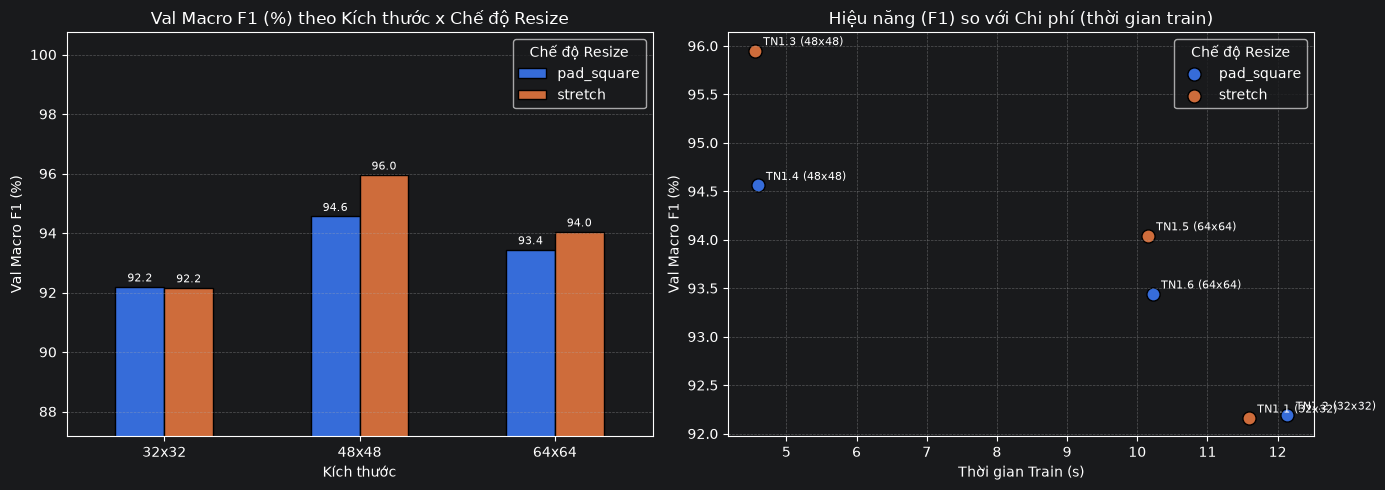

Đã lưu biểu đồ: outputs/M02_comparison_charts.png


In [18]:
# ============================================================
# Biểu đồ so sánh (để chèn thẳng vào báo cáo)
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Val Macro F1 theo Size x Mode
pivot_f1 = df_results_m02.pivot_table(
    index="Kích thước", columns="Chế độ Resize", values="Val Macro F1 (%)"
)
pivot_f1.plot(kind="bar", ax=axes[0], rot=0, edgecolor="black")
axes[0].set_title("Val Macro F1 (%) theo Kích thước x Chế độ Resize")
axes[0].set_ylabel("Val Macro F1 (%)")
axes[0].set_ylim(bottom=max(0, pivot_f1.values.min() - 5))
axes[0].legend(title="Chế độ Resize")
axes[0].grid(axis="y", linestyle="--", alpha=0.4)
for c in axes[0].containers:
    axes[0].bar_label(c, fmt="%.1f", padding=2, fontsize=8)

# (b) Hiệu năng vs Chi phí: F1 so với thời gian train
for mode, grp in df_results_m02.groupby("Chế độ Resize"):
    axes[1].scatter(grp["Thời gian Train (s)"], grp["Val Macro F1 (%)"],
                    s=90, label=mode, edgecolor="black")
    for _, r in grp.iterrows():
        axes[1].annotate(f'{r["Mã TN"]} ({r["Kích thước"]})',
                         (r["Thời gian Train (s)"], r["Val Macro F1 (%)"]),
                         textcoords="offset points", xytext=(6, 4), fontsize=8)
axes[1].set_title("Hiệu năng (F1) so với Chi phí (thời gian train)")
axes[1].set_xlabel("Thời gian Train (s)")
axes[1].set_ylabel("Val Macro F1 (%)")
axes[1].legend(title="Chế độ Resize")
axes[1].grid(linestyle="--", alpha=0.4)

plt.tight_layout()
os.makedirs("outputs", exist_ok=True)
fig.savefig("outputs/M02_comparison_charts.png", dpi=150, bbox_inches="tight")
plt.show()
print("Đã lưu biểu đồ: outputs/M02_comparison_charts.png")


**Nhận xét khoa học trong báo cáo** (điền dựa theo bảng và log in ra ở cell trên):

- So sánh ảnh hưởng của chế độ Resize (`stretch` vs `pad_square`) ở từng size — dùng đúng số liệu thật vừa in ra, không copy số liệu mẫu trong tài liệu nhiệm vụ.
- Giải thích khả dĩ: nếu `stretch` thắng, có thể do ảnh crop biển báo vốn gần vuông nên bóp méo không đáng kể, trong khi viền đen của `pad_square` tạo cạnh sắc nhân tạo gây nhiễu đặc trưng HOG ở size nhỏ.
- So sánh giữa 3 kích thước: hiệu năng (Accuracy/F1) so với chi phí (thời gian train) — cấu hình nào cân bằng tốt nhất.
- Chốt cấu hình chiến thắng bằng đúng số liệu vừa tính được ở cell trên (biến `WINNER_SIZE`, `WINNER_MODE`).

## 5. Bàn giao (Handover)

In [19]:
handover_config = {
    "winner_size": WINNER_SIZE,
    "winner_mode": WINNER_MODE,
    "winner_pixels_per_cell": list(WINNER_PPC),
    "dataset_dir": DATASET_DIR,
    "train_subdir": TRAIN_SUBDIR,
    "val_subdir": VAL_SUBDIR,
    "classes": train_classes,
}

os.makedirs("outputs", exist_ok=True)
with open("outputs/M02_handover_config.json", "w", encoding="utf-8") as f:
    json.dump(handover_config, f, ensure_ascii=False, indent=2)

print(f'"Cấu hình Tiền xử lý chiến thắng là: Size = {WINNER_SIZE}x{WINNER_SIZE}, Mode = {WINNER_MODE}"')
print()
print("Đã lưu file cấu hình bàn giao: outputs/M02_handover_config.json")
print("Để đảm bảo tính nhất quán giữa 2 bài test (không tự ý đổi size/mode).")


"Cấu hình Tiền xử lý chiến thắng là: Size = 48x48, Mode = stretch"

Đã lưu file cấu hình bàn giao: outputs/M02_handover_config.json
Để đảm bảo tính nhất quán giữa 2 bài test (không tự ý đổi size/mode).


### Tổng kết M02

- [x] Đã chạy đủ 6 cấu hình Tiền xử lý x Kích thước.
- [x] Bảng kết quả lưu tại `outputs/M02_results_6_configs.csv`.
- [x] Cấu hình chiến thắng được lưu tại `outputs/M02_handover_config.json` để M03 sử dụng lại nguyên vẹn.
- Bước tiếp theo: mở notebook `M03_experiment_2_colorspace_and_fusion.ipynb` và chạy tiếp — notebook đó sẽ tự động đọc file cấu hình này.